In [23]:
import torch
from torchattacks import PGD, FGSM
from modules import load_model, choose_dataset
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

In [24]:
# config 파일 생성용
def make_config(**kwargs):
    act = kwargs.get('act')
    replaceAll = True if kwargs.get('replaceALL') == 'all' else False
    alpha = kwargs.get('alpha')
    adv = kwargs.get('adv')
    atk_type = kwargs.get('atk_type')
    steps = kwargs.get('steps')
    eps = kwargs.get('eps')
    opt = kwargs.get('opt')
    cfg = {
        'architecture' : 'resnet18',
        'optimizer' : opt,
        'activation' : act,
        'replaceAll' : replaceAll, 
        'dataset' : 'CIFAR10',
        'batch_size' : 8,
        'num_workers' : 8,
        'adv' : adv,
        'eps' : eps,
        'alpha' : alpha,
        'atk' : atk_type,
        'steps' : steps
    }
    return cfg

def adv_attack(model, x, y, atkType = 'PGD', eps = 0.0314, alpha = 0.00784, steps = 3):
    with torch.enable_grad():
        if atkType == 'PGD':
            atk = PGD(model, eps=eps, alpha=alpha, steps=steps)
        elif atkType == 'FGSM':
            atk = FGSM(model, eps=eps)
        adv_example = atk(x, y)
    return adv_example

def visualize_fgsm_attack(original_images, attacked_images, num_images=5):
    """
    FGSM 공격 전후 이미지를 1열과 2열에 각각 시각화하는 함수

    Args:
        original_images (torch.Tensor): 원본 이미지 텐서 (batch, channel, height, width)
        attacked_images (torch.Tensor): FGSM 공격받은 이미지 텐서 (batch, channel, height, width)
        num_images (int): 시각화할 이미지 개수 (기본값: 5)
    """

    # 이미지 텐서를 PIL 이미지로 변환 (Matplotlib에서 시각화하기 위해)
    to_pil_image = ToPILImage()

    # 시각화할 이미지 개수만큼 반복
    for i in range(min(num_images, len(original_images))):
        # 원본 이미지와 공격받은 이미지 가져오기
        original_img = original_images[i]
        attacked_img = attacked_images[i]

        # 이미지 시각화 (1행 2열 subplot)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # 1열: 원본 이미지
        axes[0].imshow(to_pil_image(original_img))
        axes[0].set_title(f"Original Image {i+1}")
        axes[0].axis('off')  # 축 숨기기

        # 2열: FGSM 공격받은 이미지
        axes[1].imshow(to_pil_image(attacked_img))
        axes[1].set_title(f"Attacked Image {i+1} (FGSM)")
        axes[1].axis('off')  # 축 숨기기

        plt.show()
        
def visualize_pgd_attack(original_images, attacked_images_by_step, steps, num_images=5):
    """
    PGD 공격 단계별 이미지를 시각화하는 함수

    Args:
        original_images (torch.Tensor): 원본 이미지 텐서 (batch, channel, height, width)
        attacked_images_by_step (list of torch.Tensor): 각 PGD 단계별 공격 이미지 텐서 리스트
        steps (list of int): 각 PGD 단계 리스트 (예: [1, 5, 10])
        num_images (int): 시각화할 이미지 개수 (기본값: 5)
    """

    # 이미지 텐서를 PIL 이미지로 변환 (Matplotlib에서 시각화하기 위해)
    to_pil_image = ToPILImage()

    # 시각화할 이미지 개수만큼 반복
    for i in range(min(num_images, len(original_images))):
        # 원본 이미지와 각 단계별 공격 이미지 가져오기
        original_img = original_images[i]
        attacked_imgs = [attacked_images_by_step[j][i] for j in range(len(steps))]

        # 이미지 시각화 (1행 (단계 수 + 1)열 subplot)
        fig, axes = plt.subplots(1, len(steps) + 1, figsize=(15, 5))

        # 1열: 원본 이미지
        axes[0].imshow(to_pil_image(original_img))
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        # 나머지 열: 각 단계별 PGD 공격받은 이미지
        for j, (attacked_img, step) in enumerate(zip(attacked_imgs, steps)):
            axes[j+1].imshow(to_pil_image(attacked_img))
            axes[j+1].set_title(f"Attacked Image (Step {step})")
            axes[j+1].axis('off')

        plt.show()

In [25]:
ckpt = 'ckpt/CIFAR10_50loss/all/Adam/relu/relu_ALL_CIFAR10_Adam_epoch=87_Robust_acc=0.6034.ckpt'

In [26]:
fgsm_cfg = make_config(act='relu', opt = 'adam', replaceALL=True, alpha=None, adv=True, atk_type='FGSM', eps=0.0314)
model = load_model(ckpt=ckpt, config=fgsm_cfg)

/home/ubuntu/brelu/ReAct-Net/custom_resnet/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ModelWrapper(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bottleneckLayer): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [27]:
_, valloader = choose_dataset(config=fgsm_cfg)

Files already downloaded and verified
Files already downloaded and verified


In [28]:
toImage = ToPILImage()

In [29]:
x, y = next(iter(valloader))

In [30]:
x.shape

torch.Size([8, 3, 32, 32])

# FGSM Attack

In [31]:
fgsm_example = adv_attack(model, x, y, 'FGSM')

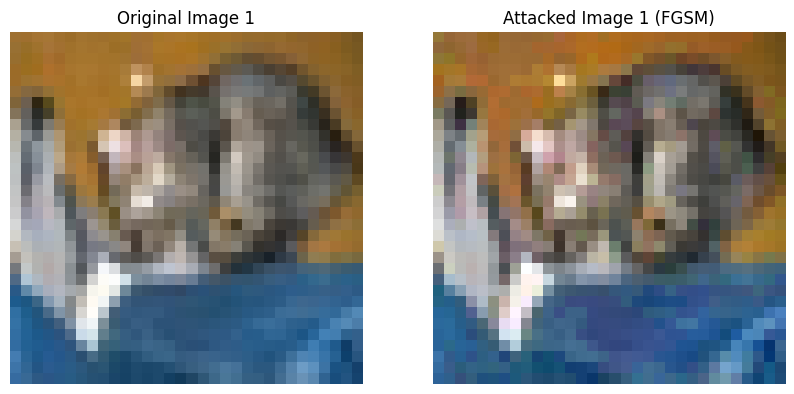

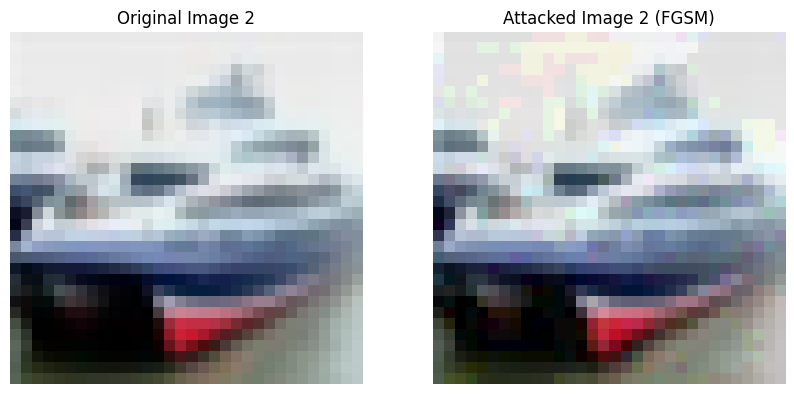

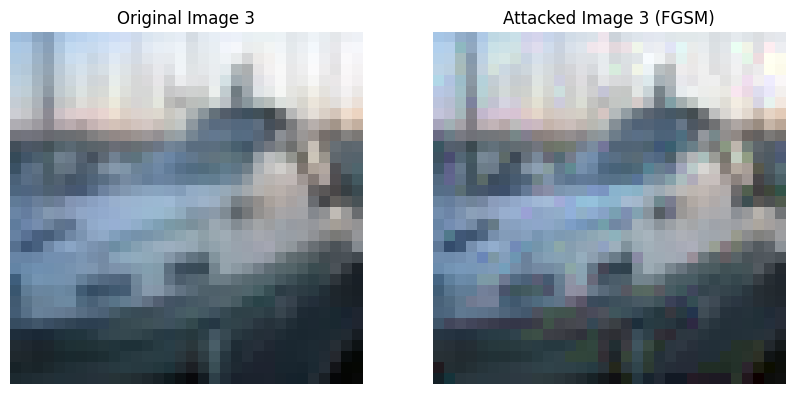

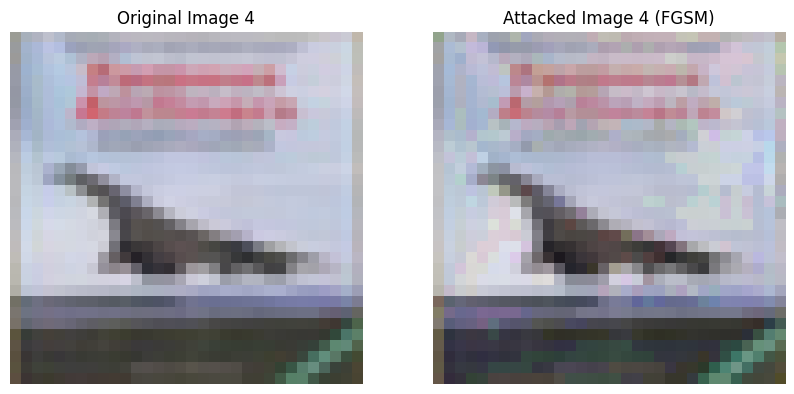

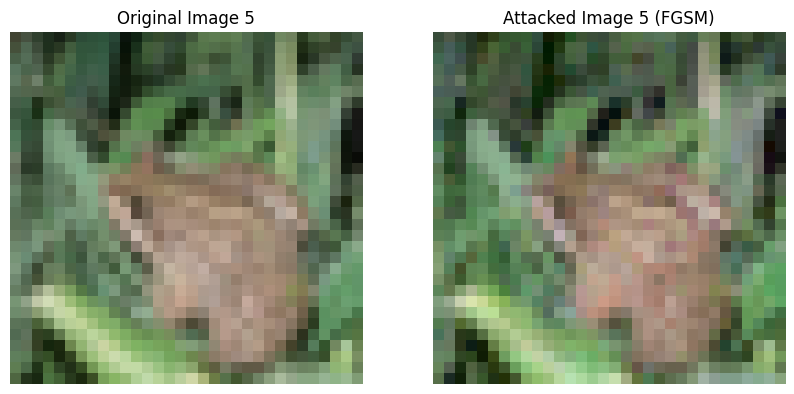

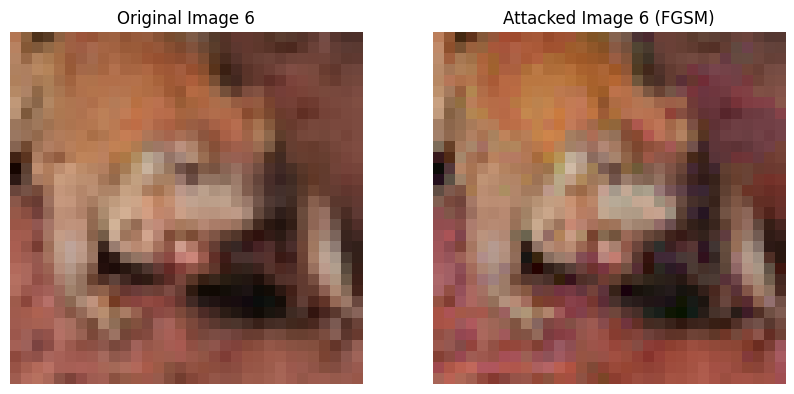

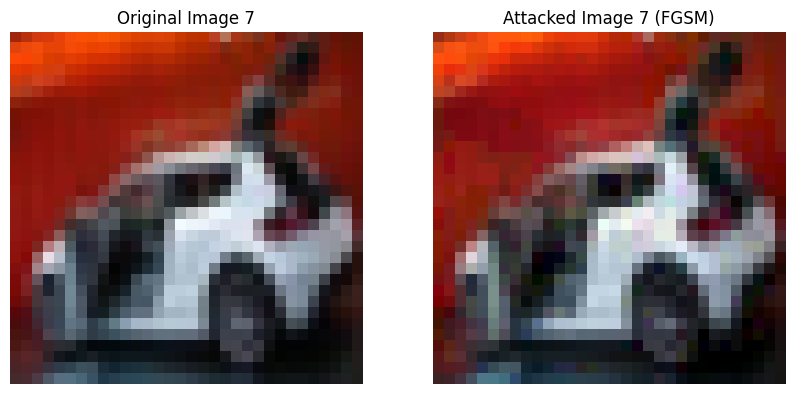

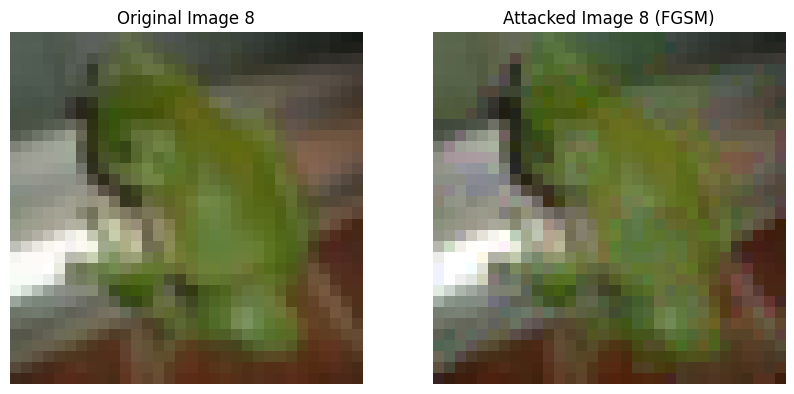

In [32]:
visualize_fgsm_attack(x, fgsm_example, 8)

# PGD Attack

In [33]:
steps = [3, 7]
pgd_examples = []

for step in steps:
    pgd_examples.append(adv_attack(model, x, y, 'PGD', steps=step))

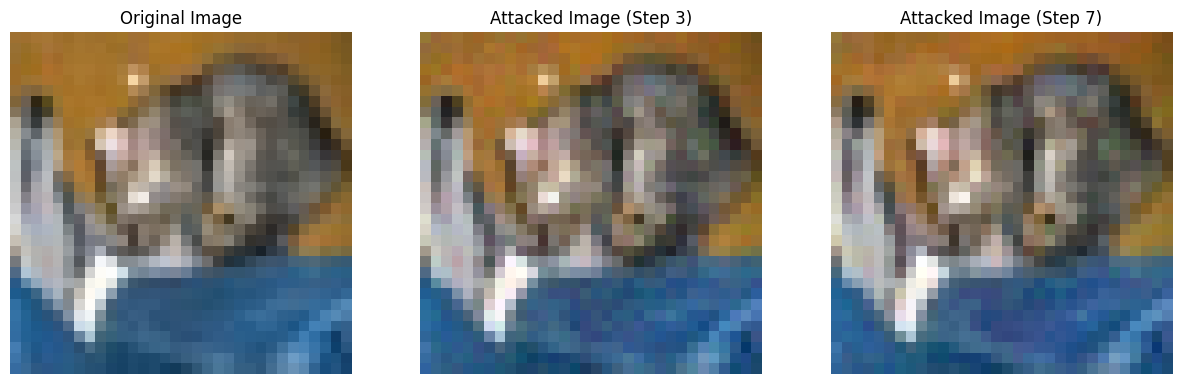

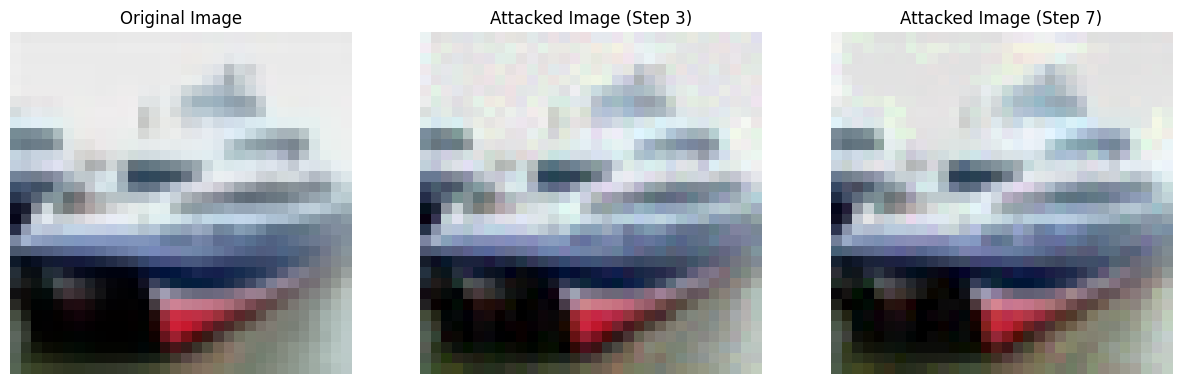

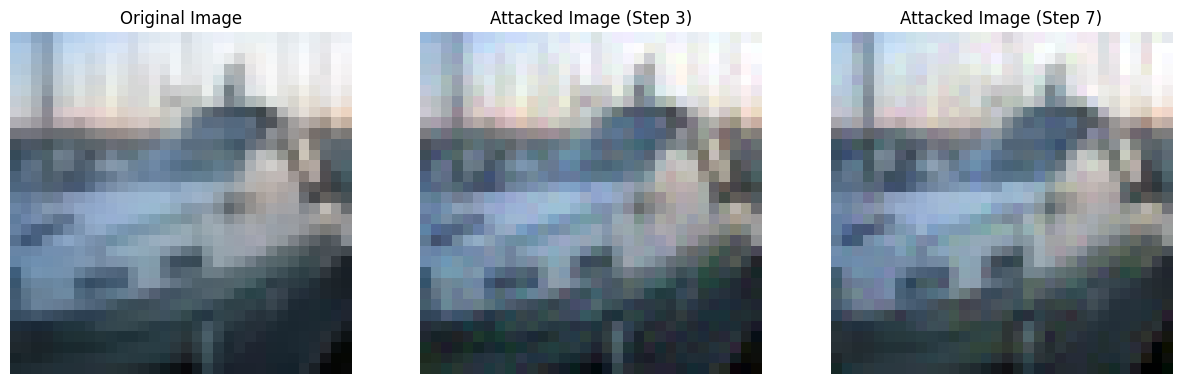

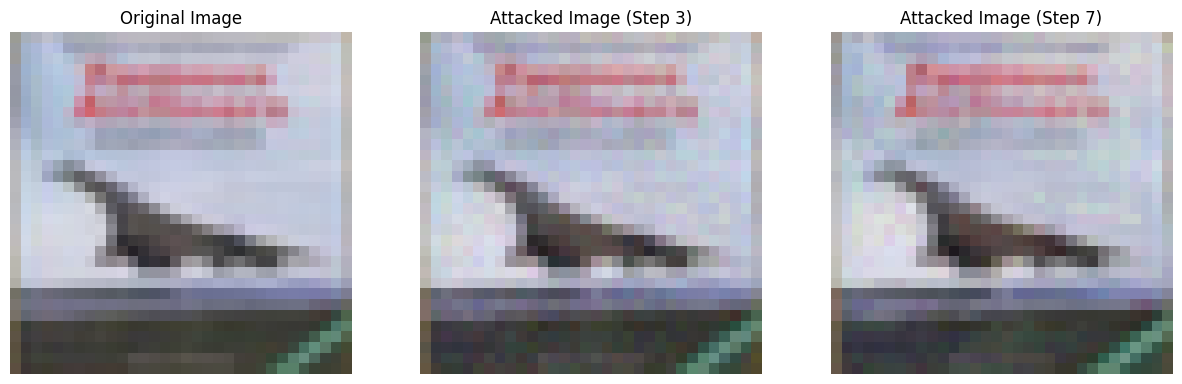

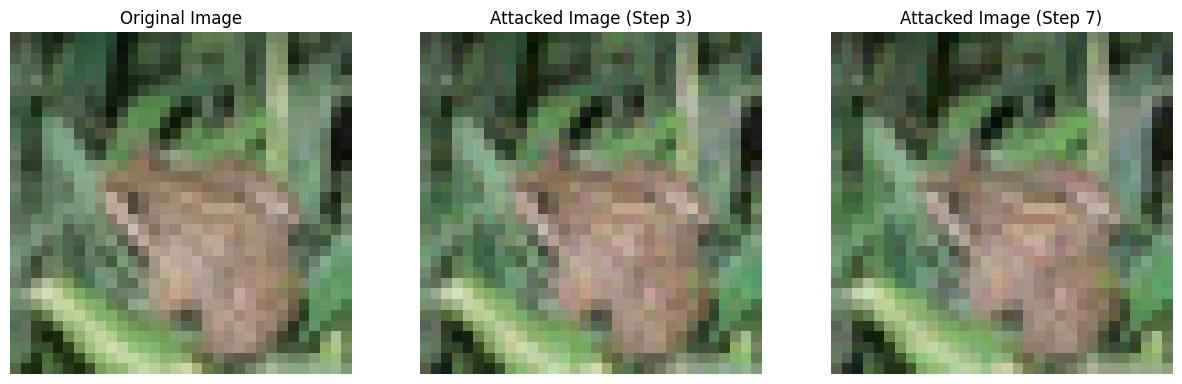

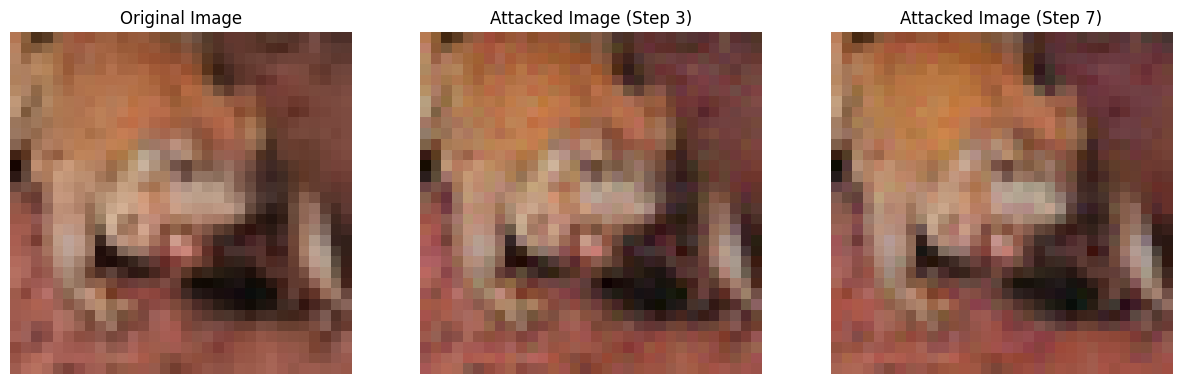

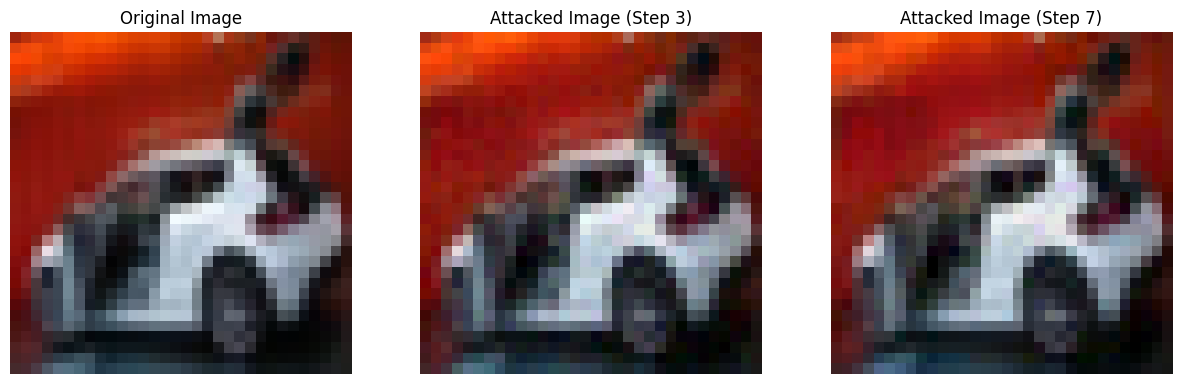

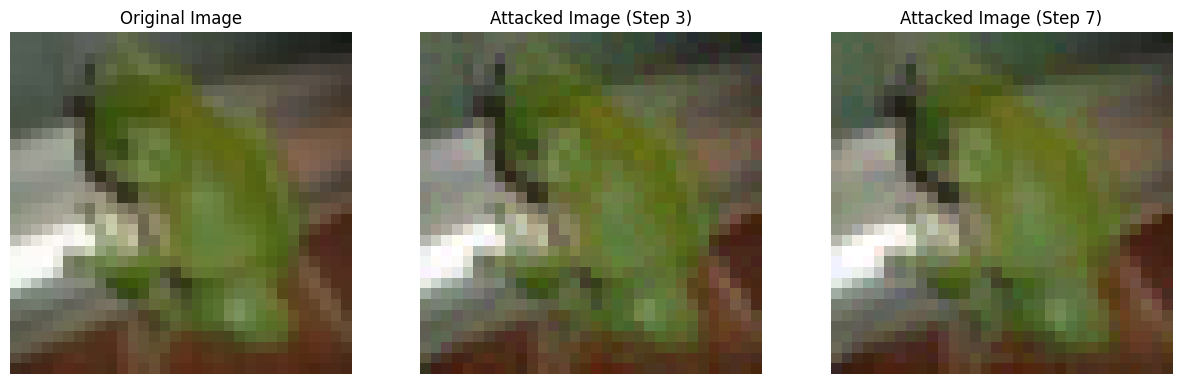

In [34]:
visualize_pgd_attack(x, pgd_examples, steps, 8)

# 신뢰도 함께 표시

In [35]:
def visualize_pgd_attack_with_label_confidence(model, original_images, attacked_images_by_step, steps, labels, num_images=5):
    """
    PGD 공격 단계별 이미지와 특정 라벨에 대한 모델 신뢰도를 시각화하는 함수

    Args:
        model (torch.nn.Module): 사용할 모델
        original_images (torch.Tensor): 원본 이미지 텐서 (batch, channel, height, width)
        attacked_images_by_step (list of torch.Tensor): 각 PGD 단계별 공격 이미지 텐서 리스트
        steps (list of int): 각 PGD 단계 리스트 (예: [1, 5, 10])
        labels (torch.Tensor or list of int): 각 이미지의 정답 라벨
        num_images (int): 시각화할 이미지 개수 (기본값: 5)
    """

    # 이미지 텐서를 PIL 이미지로 변환 (Matplotlib에서 시각화하기 위해)
    to_pil_image = ToPILImage()

    # 모델 평가 모드 설정
    model.eval()

    # 시각화할 이미지 개수만큼 반복
    for i in range(min(num_images, len(original_images))):
        # 원본 이미지와 각 단계별 공격 이미지 가져오기
        original_img = original_images[i]
        attacked_imgs = [attacked_images_by_step[j][i] for j in range(len(steps))]

        # 이미지 시각화 (1행 (단계 수 + 1)열 subplot)
        fig, axes = plt.subplots(1, len(steps) + 1, figsize=(15, 5))

        # 1열: 원본 이미지
        axes[0].imshow(to_pil_image(original_img))
        
        with torch.no_grad():
            output = model(original_img.unsqueeze(0))  # 모델 입력 형태에 맞춰 차원 추가
            confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100

        axes[0].set_title(f"Original Image\nConfidence: {confidence:.2f}%")
        axes[0].axis('off')

        # 나머지 열: 각 단계별 PGD 공격받은 이미지
        for j, (attacked_img, step) in enumerate(zip(attacked_imgs, steps)):
            axes[j+1].imshow(to_pil_image(attacked_img))

            # 모델 신뢰도 계산 (특정 라벨에 대한 확률)
            with torch.no_grad():
                output = model(attacked_img.unsqueeze(0))  # 모델 입력 형태에 맞춰 차원 추가
                confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100

            axes[j+1].set_title(f"Attacked Image (Step {step})\nConfidence: {confidence:.2f}%")
            axes[j+1].axis('off')

        plt.show()

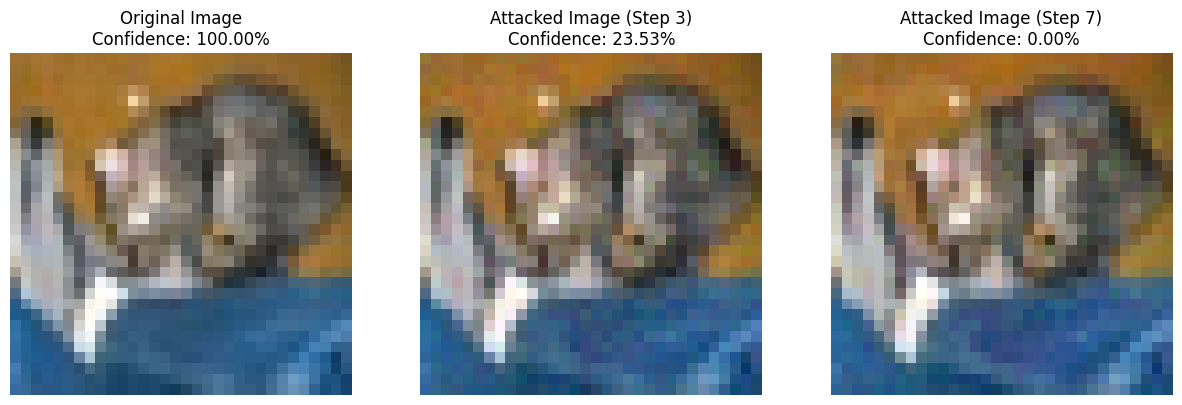

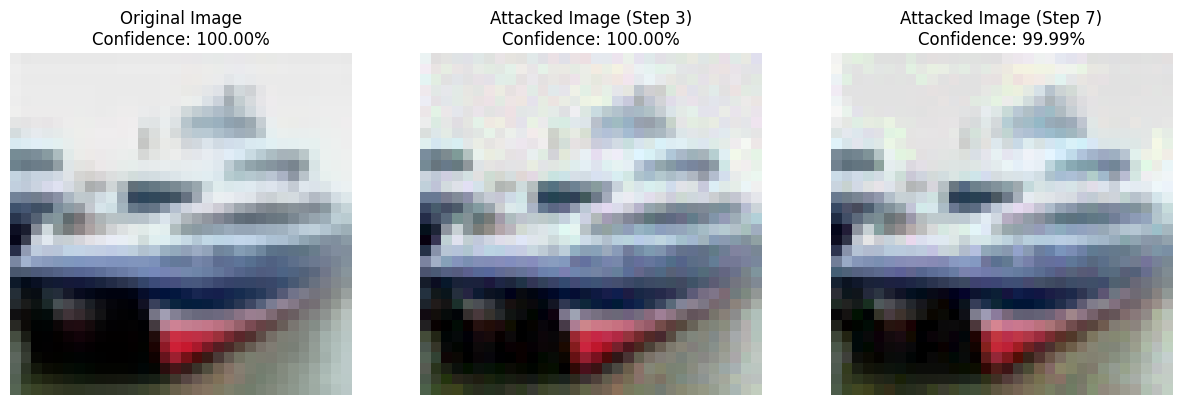

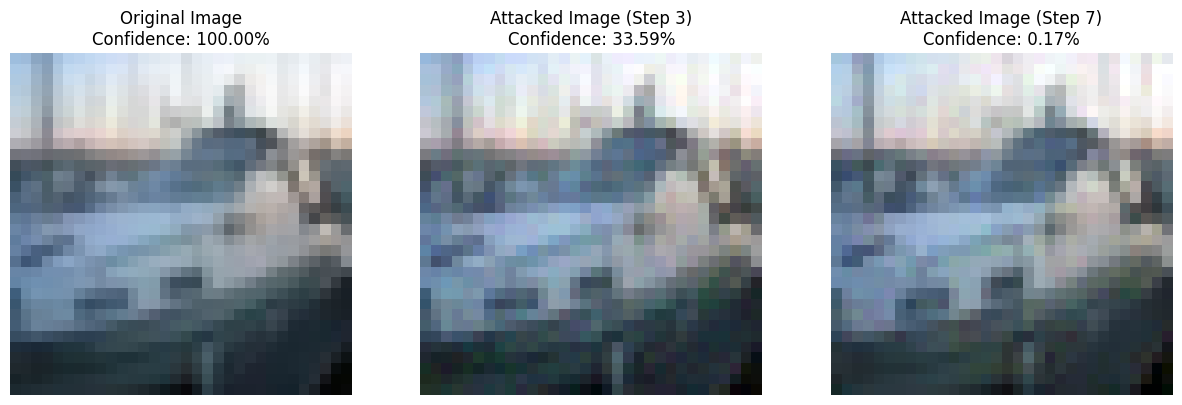

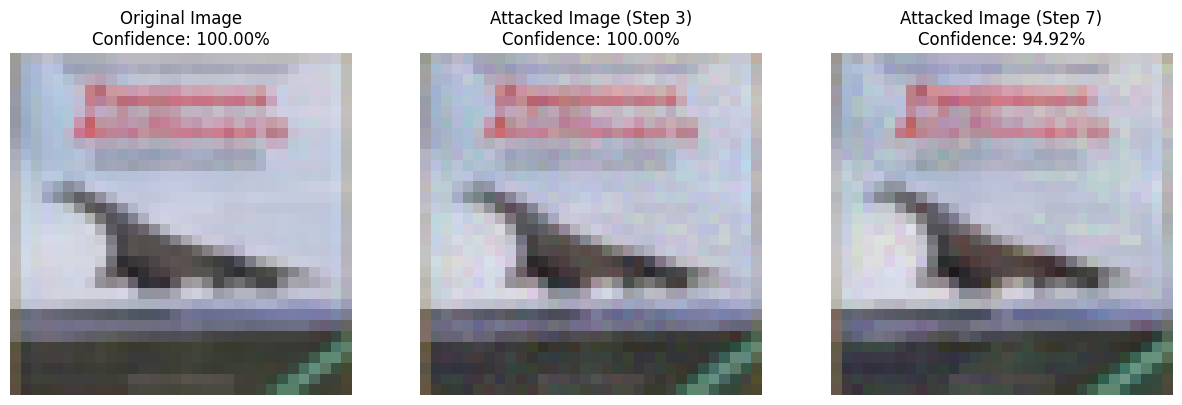

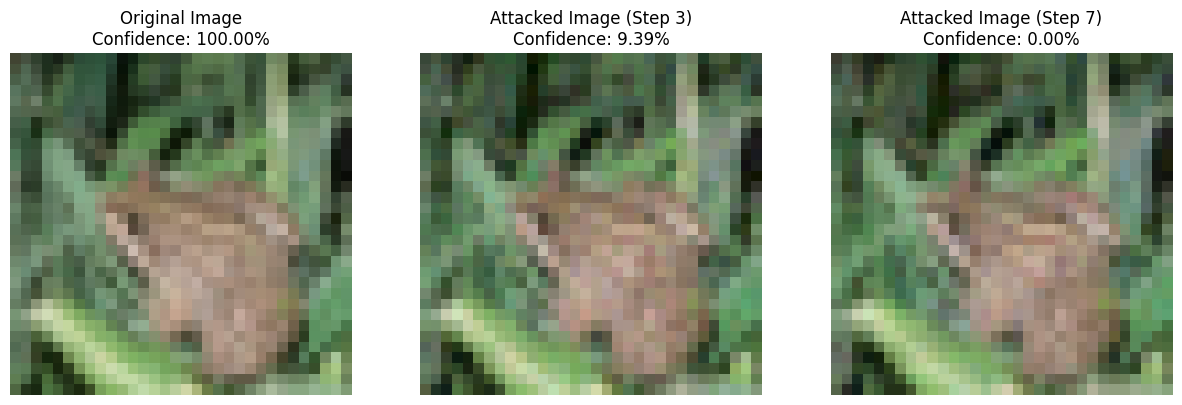

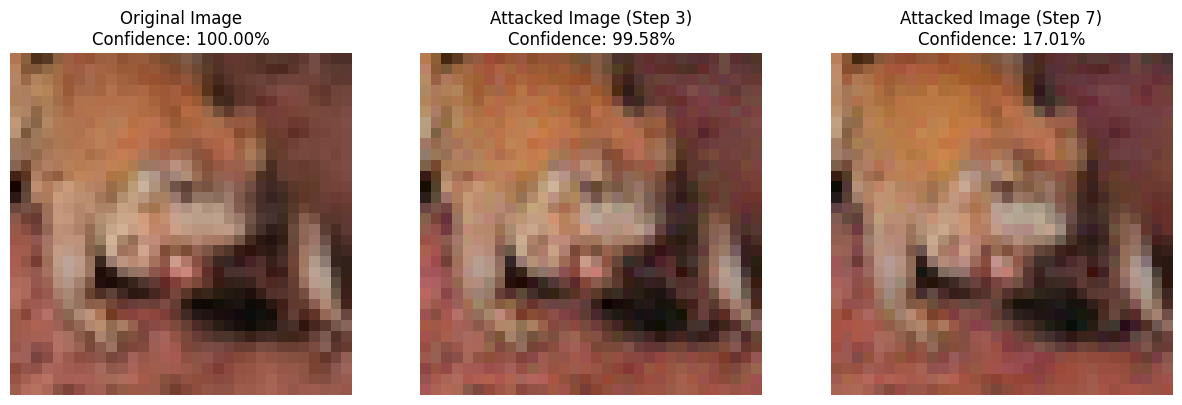

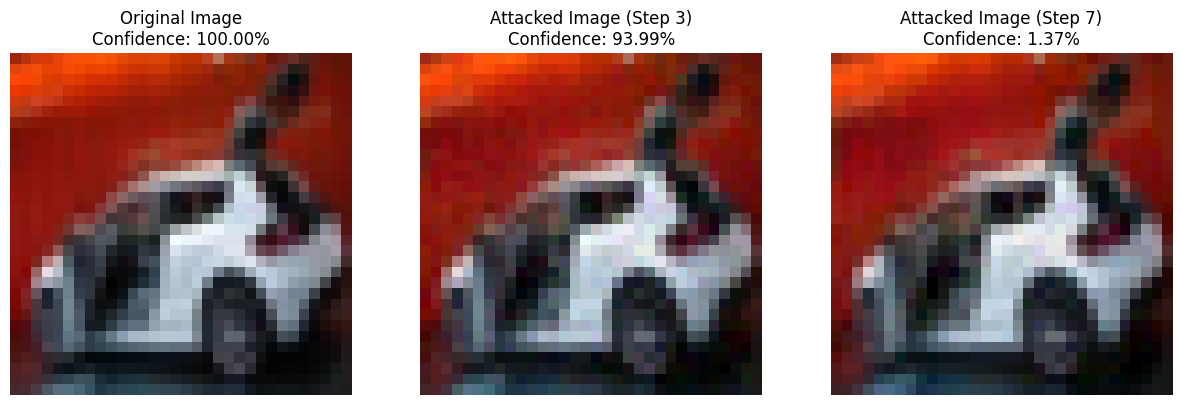

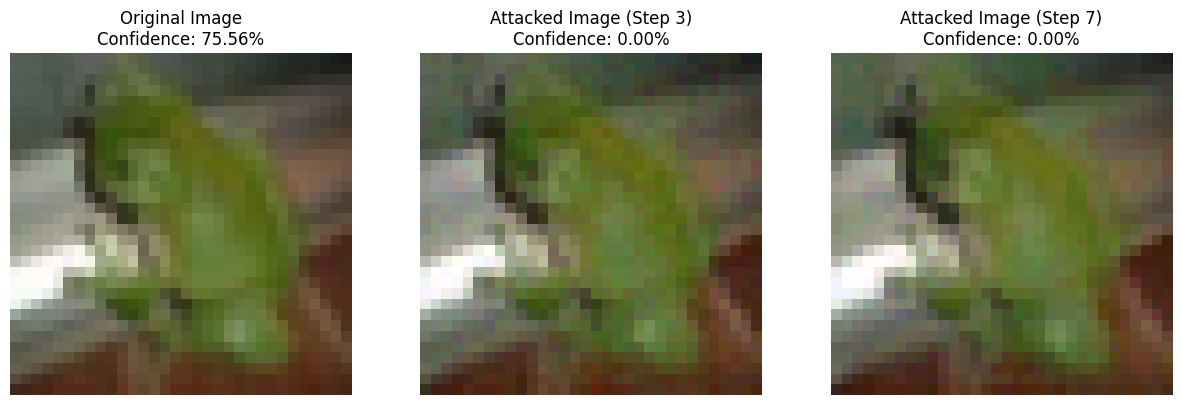

In [36]:
visualize_pgd_attack_with_label_confidence(model.to('cuda:2'), x.to('cuda:2'), pgd_examples, steps, y, 8)

In [37]:
def visualize_fgsm_attack_with_confidence(model, original_images, attacked_images, labels, num_images=5, device="cuda:2"):
    """
    FGSM 공격 전후 이미지와 모델 신뢰도를 시각화하는 함수 (라벨 추가)

    Args:
        model (torch.nn.Module): 사용할 모델
        original_images (torch.Tensor): 원본 이미지 텐서 (batch, channel, height, width)
        attacked_images (torch.Tensor): FGSM 공격받은 이미지 텐서 (batch, channel, height, width)
        labels (torch.Tensor or list of int): 각 이미지의 정답 라벨
        num_images (int): 시각화할 이미지 개수 (기본값: 5)
        device (str): 사용할 장치 ("cuda:2" or "cpu")
    """

    # 이미지 텐서를 PIL 이미지로 변환 (Matplotlib에서 시각화하기 위해)
    to_pil_image = ToPILImage()

    # 모델 평가 모드 설정
    model.eval()

    # 시각화할 이미지 개수만큼 반복
    for i in range(min(num_images, len(original_images))):
        # 원본 이미지와 공격받은 이미지 가져오기
        original_img = original_images[i].unsqueeze(0)  # 배치 차원 추가
        attacked_img = attacked_images[i].unsqueeze(0)  # 배치 차원 추가

        # 이미지 시각화 (1행 2열 subplot)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # 1열: 원본 이미지
        axes[0].imshow(to_pil_image(original_img.squeeze(0)))  # 배치 차원 제거 후 시각화

        # 원본 이미지 신뢰도 계산
        with torch.no_grad():
            output = model(original_img.to(device))
            confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100  # 백분율로 변환

        axes[0].set_title(f"Original Image\nConfidence: {confidence:.2f}%")
        axes[0].axis('off')

        # 2열: FGSM 공격받은 이미지
        axes[1].imshow(to_pil_image(attacked_img.squeeze(0)))  # 배치 차원 제거 후 시각화

        # 공격받은 이미지 신뢰도 계산
        with torch.no_grad():
            output = model(attacked_img.to(device))
            confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100  # 백분율로 변환

        axes[1].set_title(f"Attacked Image (FGSM)\nConfidence: {confidence:.2f}%")
        axes[1].axis('off')

        plt.show()

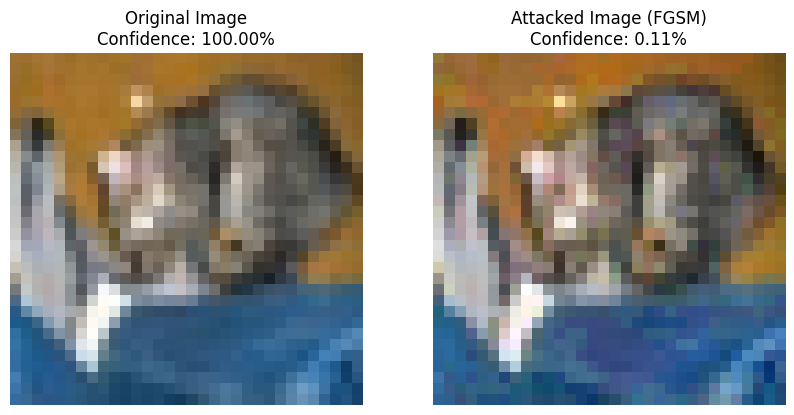

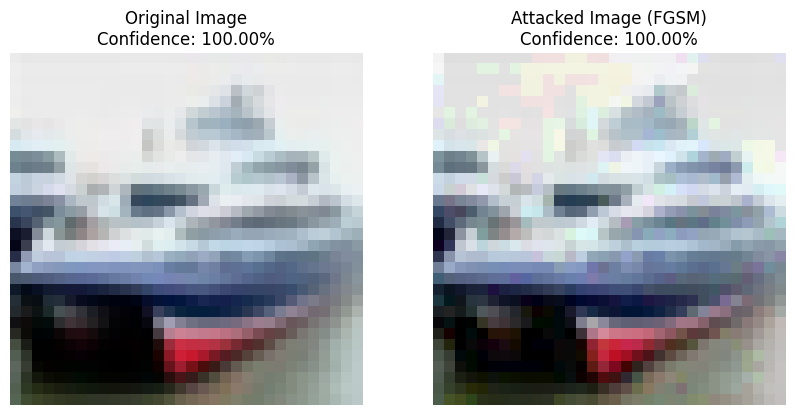

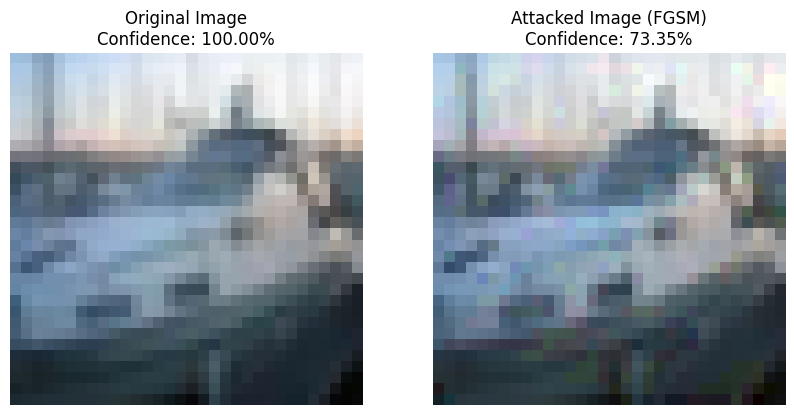

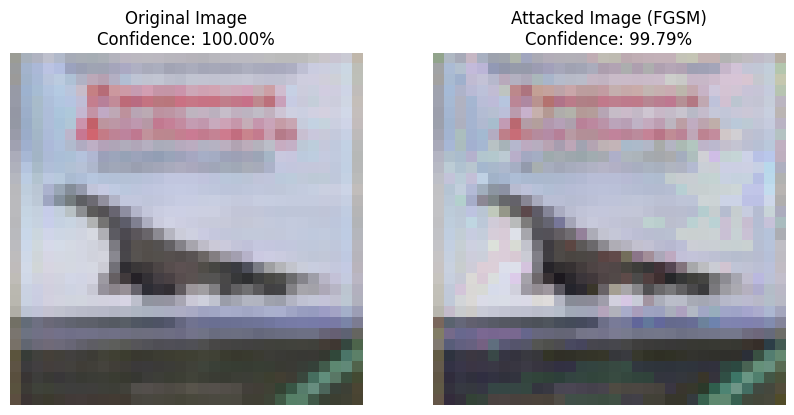

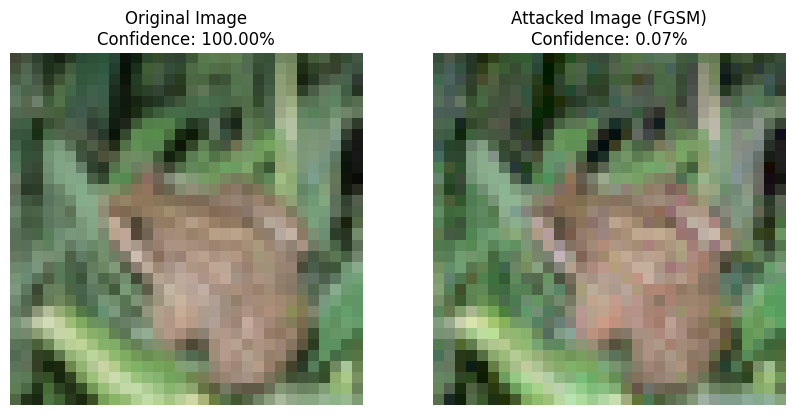

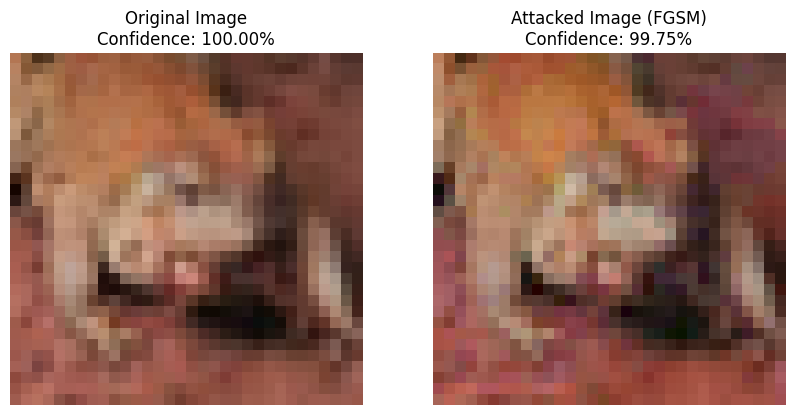

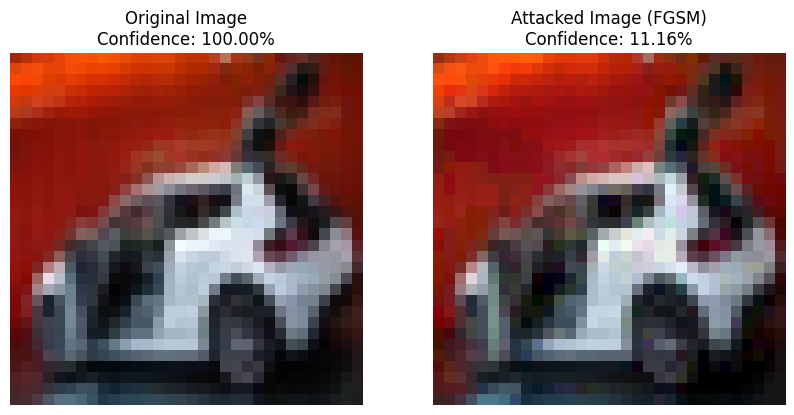

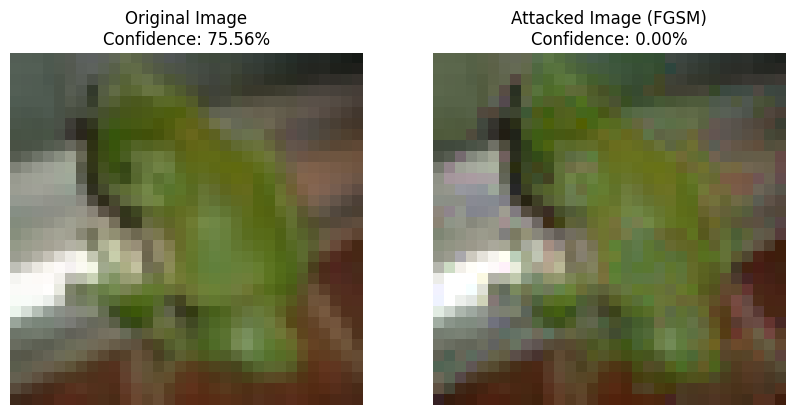

In [38]:
visualize_fgsm_attack_with_confidence(model, x, fgsm_example, y, 8)

In [44]:
def vis(model, original_images, labels, fgsm_images, pgd_images, steps, num_images=5):
    to_pil_image = ToPILImage()
    
    model.eval()
    
    for i in range(min(num_images, len(original_images))):
        origin = original_images[i].unsqueeze(0)
        fgsm = fgsm_images[i].unsqueeze(0)
        pgd_imgs = [pgd_images[j][i] for j in range(len(steps))]
        
        fig, axes = plt.subplots(1, len(steps) + 2, figsize = (15, 5))
        
        # 1열: 원본 이미지
        axes[0].imshow(to_pil_image(origin.squeeze(0)))
        
        with torch.no_grad():
            output = model(origin.to(model.device))
            confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100
        
        axes[0].set_title(f"Original Image\nConfidence: {confidence:.2f}%")
        axes[0].axis('off')
        
        
        # 2열: FGSM 공격 이미지
        axes[1].imshow(to_pil_image(fgsm.squeeze(0)))
        
        with torch.no_grad():
            output = model(fgsm.to(model.device))
            confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100
            
        axes[1].set_title(f"Attacked Image (FGSM)\nConfidence: {confidence:.2f}%")
        axes[1].axis('off')
        
        # 나머지 열: PGD 공격 이미지
        for j, (pgd_img, step) in enumerate(zip(pgd_imgs, steps)):
            axes[j+2].imshow(to_pil_image(pgd_img))
            
            with torch.no_grad():
                output = model(pgd_img.unsqueeze(0).to(model.device))
                confidence = torch.softmax(output, dim=1)[0, labels[i]].item() * 100
            
            axes[j+2].set_title(f"Attacked Image (PGD {step} Steps)\nConfidence: {confidence:.2f}%")
            axes[j+2].axis('off')
            
        plt.show()

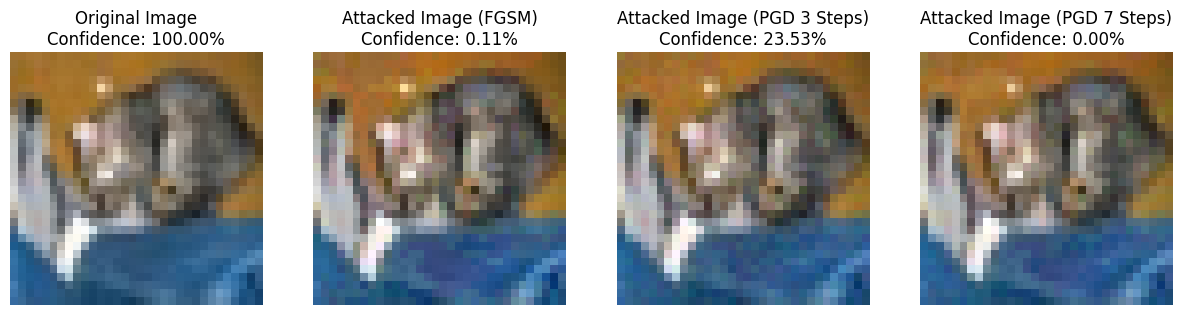

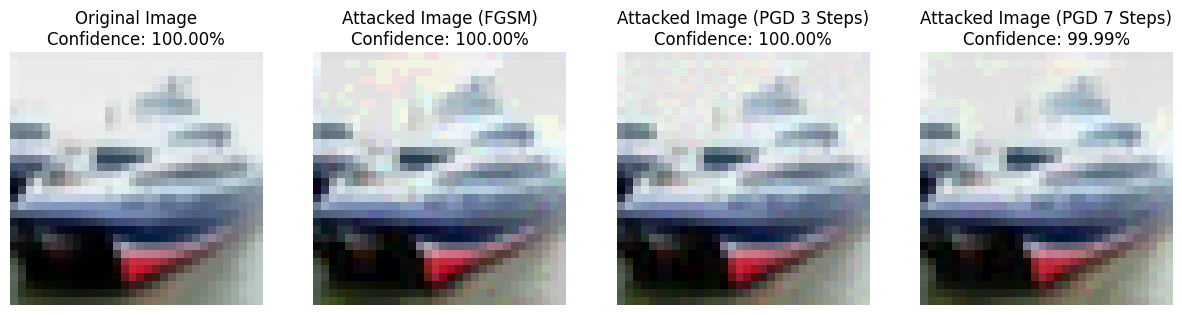

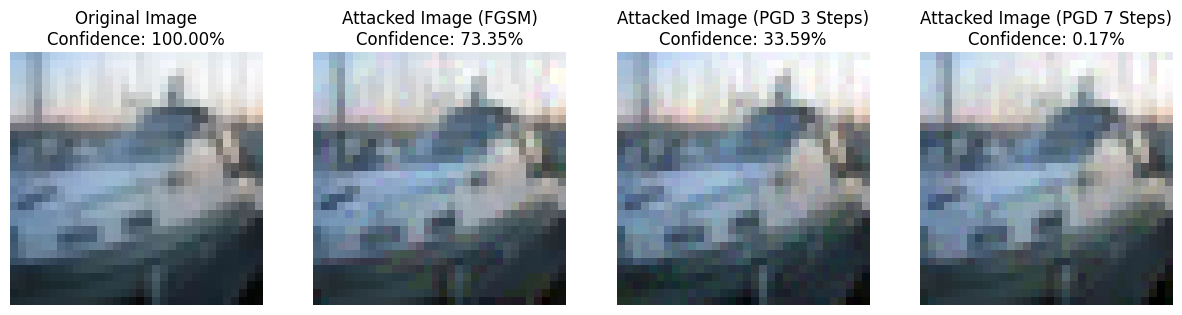

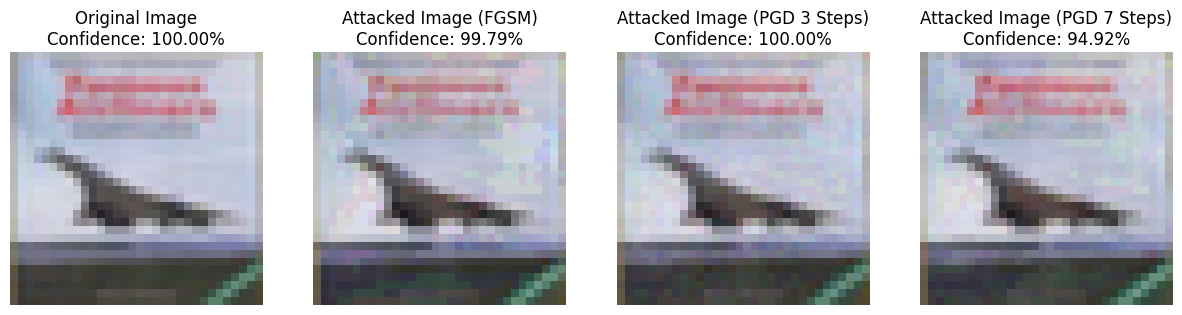

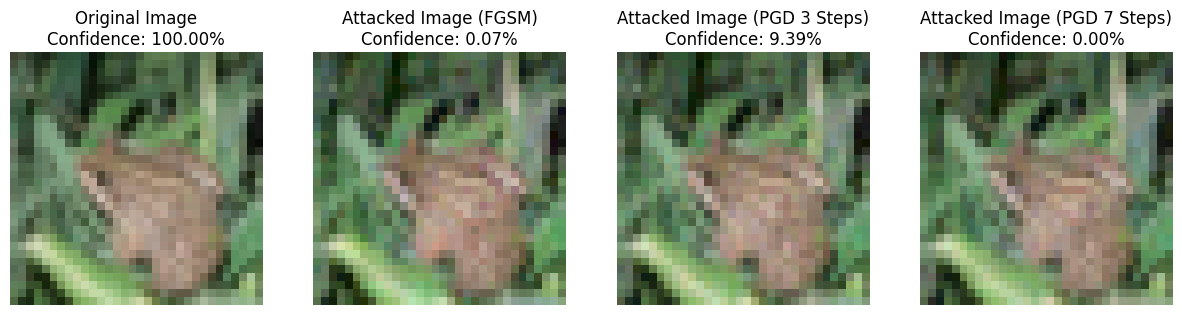

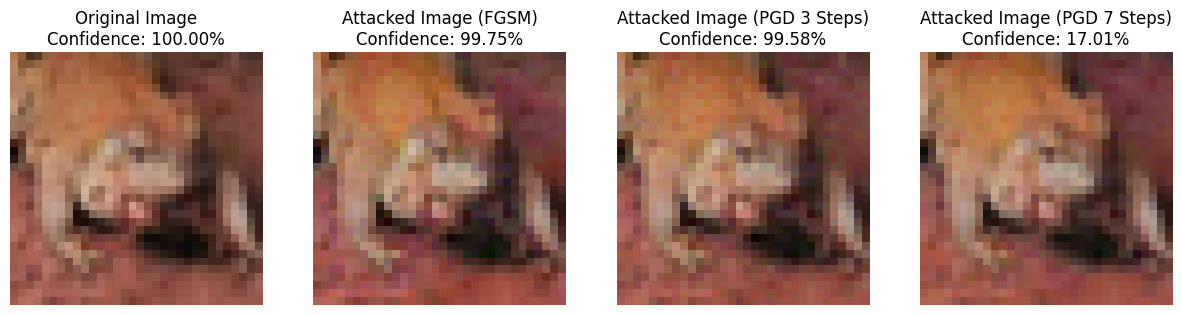

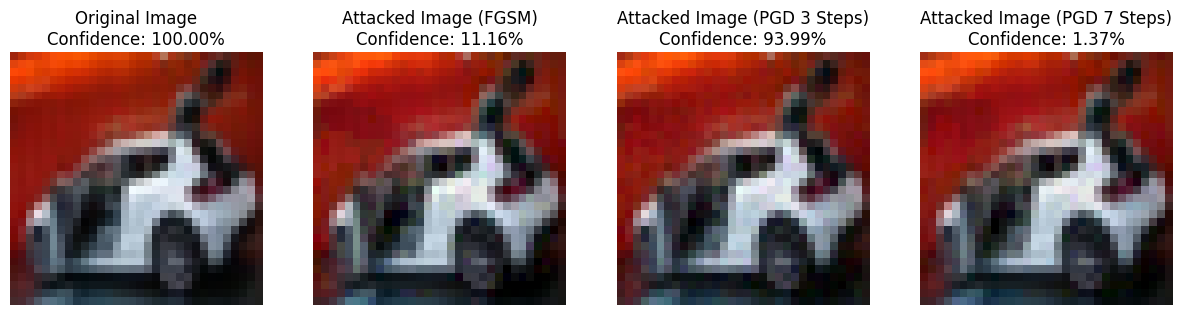

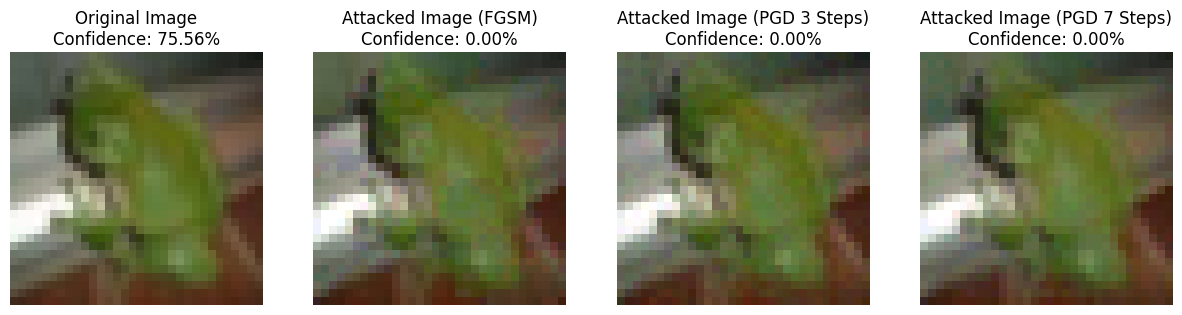

In [45]:
vis(model, x, y, fgsm_example, pgd_examples, steps, 8)

In [41]:
import torch.nn as nn

In [42]:
def append_dropout(model, rate = 0.5):
    for name, module in model.named_children():
        if len(list(module.children())) > 0:
            append_dropout(module)
        if isinstance(module, nn.ReLU):
            dropout_relu = nn.Sequential(module, nn.Dropout2d(p = rate, inplace=True))
            setattr(model, name, dropout_relu)

In [43]:
append_dropout(model)
print(model)

LitAutoEncoder(
  (encoder): ModelWrapper(
    (cnn): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): Sequential(
        (0): ReLU(inplace=True)
        (1): Dropout2d(p=0.5, inplace=True)
      )
      (maxpool): Identity()
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (activation): Sequential(
            (0): ReLU(inplace=True)
            (1): Dropout2d(p=0.5, inplace=True)
          )
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (bottleneckLayer): Sequential(
 